<a href="https://colab.research.google.com/github/Vignesshwar-Viswanathan/clinical-notes-heart-disease-prediction/blob/main/Heart_Disease_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1) Load data
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets

print("Raw feature shape:", X.shape)
print("Raw target distribution:\n", pd.Series(y.values.ravel()).value_counts())

# 2) Convert multi-class target (0–4) to binary: 0 = no disease, 1 = disease
y_binary = np.where(y.values.ravel() > 0, 1, 0)

# 3) Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns

# 4) Define preprocessing pipelines
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, numeric_cols),
    ("cat", cat_pipe, categorical_cols)
])

# 5) Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Raw feature shape: (303, 13)
Raw target distribution:
 0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64
Train size: (242, 13), Test size: (61, 13)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Separate numeric and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(exclude=["int64", "float64"]).columns

# Define transformers
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

# Fit-transform training, transform testing
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("Preprocessing ready.")
print("Processed shapes:", X_train_proc.shape, X_test_proc.shape)

Preprocessing ready.
Processed shapes: (242, 13) (61, 13)


Using device: cpu
Starting training with Best Model Checkpointing...
Epoch   0 | Loss: 0.6969 | Test Acc: 0.8197 | Best: 0.8197
Epoch  20 | Loss: 0.3478 | Test Acc: 0.8361 | Best: 0.8852
Epoch  40 | Loss: 0.3031 | Test Acc: 0.8361 | Best: 0.8852
Epoch  60 | Loss: 0.2638 | Test Acc: 0.8361 | Best: 0.8852
Epoch  80 | Loss: 0.2496 | Test Acc: 0.8197 | Best: 0.8852
Epoch 100 | Loss: 0.2424 | Test Acc: 0.8197 | Best: 0.8852
Epoch 120 | Loss: 0.2165 | Test Acc: 0.8361 | Best: 0.8852
Epoch 140 | Loss: 0.2198 | Test Acc: 0.8361 | Best: 0.8852
Epoch 160 | Loss: 0.2273 | Test Acc: 0.8197 | Best: 0.8852
Epoch 180 | Loss: 0.2226 | Test Acc: 0.8361 | Best: 0.8852
Epoch 199 | Loss: 0.2884 | Test Acc: 0.8197 | Best: 0.8852

Training finished. Loading best model from epoch with accuracy: 0.8852

Final Test Accuracy (Best Model): 0.8852

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89  

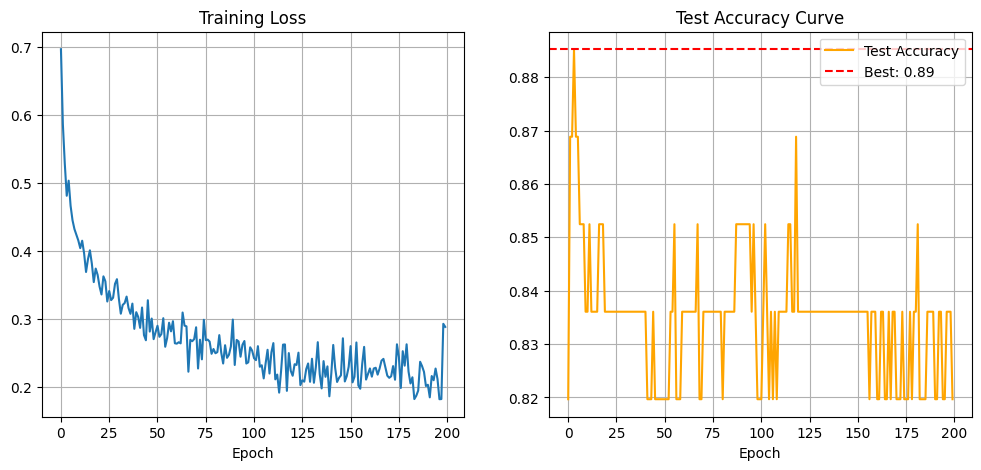

In [ ]:
# CELL: High-Capacity Custom MLP (Optimized for Small Data + Best Model Saving)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import copy  # Needed to save the best model weights

# Set seed for reproducibility and stability
torch.manual_seed(42)

# Assume X_train_proc, X_test_proc, y_train, y_test are available from Block 1.
device = torch.device("cpu")
print("Using device:", device)

# Convert processed arrays -> tensors
X_train_t = torch.tensor(X_train_proc, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_proc, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32).to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

# Slightly larger batch size (32) creates smoother gradients than 16
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

# ---------- REFINED ROBUST MLP (DEEPER) ----------
class RobustMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            # Layer 1: Wider initial layer
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Dropout(0.4),

            # Layer 2: Intermediate layer added for more complexity
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Dropout(0.4),

            # Layer 3: Bottleneck to 32
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Dropout(0.4),

            # Output Layer
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = RobustMLP(X_train_proc.shape[1]).to(device)

# AdamW with slightly reduced LR and stronger weight decay
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.02)
criterion = nn.BCEWithLogitsLoss()

# Cosine Annealing Scheduler: Smoothly lowers LR to 0
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

epochs = 200
train_losses = []
test_accs = []

best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print("Starting training with Best Model Checkpointing...")

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Step the scheduler
    scheduler.step()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Evaluate
    model.eval()
    with torch.no_grad():
        logits = model(X_test_t)
        probs = torch.sigmoid(logits)
        labels = (probs > 0.5).float()
        acc = accuracy_score(y_test, labels.cpu().numpy())
        test_accs.append(acc)

        # SAVE BEST MODEL
        if acc > best_acc:
            best_acc = acc
            best_model_wts = copy.deepcopy(model.state_dict())

    if epoch % 20 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Test Acc: {acc:.4f} | Best: {best_acc:.4f}")

# -------- LOAD BEST MODEL --------
print(f"\nTraining finished. Loading best model from epoch with accuracy: {best_acc:.4f}")
model.load_state_dict(best_model_wts)

# Final Eval on Best Model
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    probs = torch.sigmoid(logits)
    final_labels = (probs > 0.5).float()

final_acc = accuracy_score(y_test, final_labels.cpu().numpy())
print("\nFinal Test Accuracy (Best Model):", round(final_acc, 4))

print("\nClassification Report:")
print(classification_report(y_test, final_labels.cpu().numpy()))

# Graphs
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(test_accs, color='orange', label='Test Accuracy')
# Draw a line for the best accuracy
plt.axhline(y=best_acc, color='r', linestyle='--', label=f'Best: {best_acc:.2f}')
plt.title("Test Accuracy Curve")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)

plt.show()

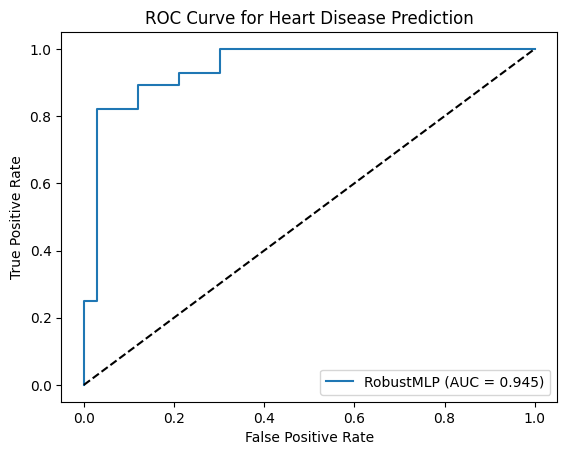

In [ ]:
import torch
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Set the model to evaluation mode (turns off dropout, etc.)
model.eval()

# 2. Convert test data to a PyTorch float tensor if it's a numpy array
if not torch.is_tensor(X_test_proc):
    X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32)
else:
    X_test_tensor = X_test_proc

# 3. Run inference without calculating gradients (saves memory/time)
with torch.no_grad():
    outputs = model(X_test_tensor)

    # If your PyTorch model outputs raw logits (no sigmoid at the end), uncomment the next line:
    # outputs = torch.sigmoid(outputs)

    # Convert back to a 1D numpy array for scikit-learn
    y_prob_mlp = outputs.cpu().numpy().ravel()

# --- Plotting the ROC Curve ---
plt.figure()

fpr, tpr, _ = roc_curve(y_test, y_prob_mlp)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"RobustMLP (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Heart Disease Prediction")
plt.legend()
plt.show()

Shapes: (242, 13) (61, 13)

Logistic Regression Test Accuracy: 0.8689

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



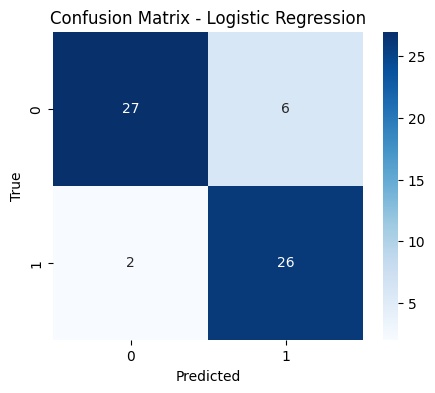

In [ ]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_proc, y_train)

# Predictions
y_pred_log = log_reg.predict(X_test_proc)

# Accuracy
acc_log = accuracy_score(y_test, y_pred_log)
print("Shapes:", X_train_proc.shape, X_test_proc.shape)
print(f"\nLogistic Regression Test Accuracy: {acc_log:.4f}")

# Classification report
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Shapes: (242, 13) (61, 13)

Linear Regression MSE: 0.1119
Linear Regression R²: 0.5492
Linear Regression (rounded) accuracy-like score: 0.8689

For reference, MLP accuracy was ≈ 0.8361

Classification Report (Linear Regression):
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



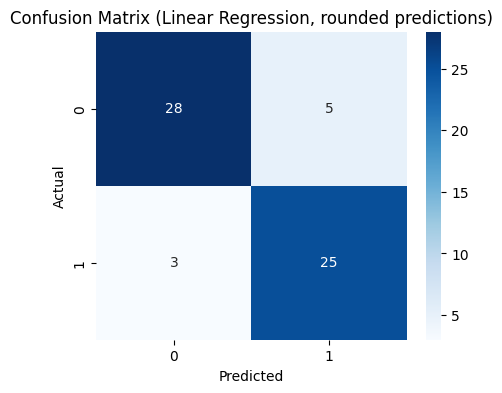

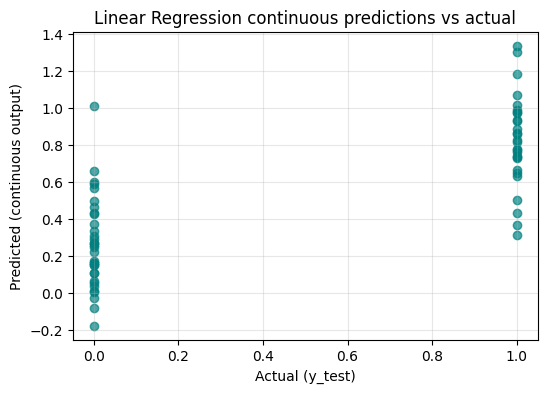

In [ ]:
# Linear Regression (for comparison)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Train Linear Regression
linreg = LinearRegression()
linreg.fit(X_train_proc, y_train)

# Predict (continuous values)
y_pred_continuous = linreg.predict(X_test_proc)

# Round predictions to 0/1 to mimic classification
y_pred_rounded = np.round(y_pred_continuous).astype(int)

# Evaluate numeric regression metrics
mse = mean_squared_error(y_test, y_pred_continuous)
r2 = r2_score(y_test, y_pred_continuous)
accuracy_like = accuracy_score(y_test, y_pred_rounded)

print("Shapes:", X_train_proc.shape, X_test_proc.shape)
print(f"\nLinear Regression MSE: {mse:.4f}")
print(f"Linear Regression R²: {r2:.4f}")
print(f"Linear Regression (rounded) accuracy-like score: {accuracy_like:.4f}")
print("\nFor reference, MLP accuracy was ≈ 0.8361")

# Classification report (based on rounded preds)
print("\nClassification Report (Linear Regression):")
print(classification_report(y_test, y_pred_rounded))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rounded)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Linear Regression, rounded predictions)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Scatter plot: continuous vs actual
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_continuous, color='teal', alpha=0.7)
plt.xlabel("Actual (y_test)")
plt.ylabel("Predicted (continuous output)")
plt.title("Linear Regression continuous predictions vs actual")
plt.grid(True, alpha=0.3)
plt.show()

Shapes: (242, 13) (61, 13)

Decision Tree Test Accuracy: 0.7869

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        33
           1       0.80      0.71      0.75        28

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



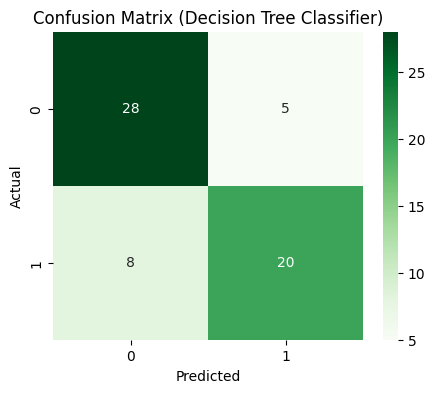

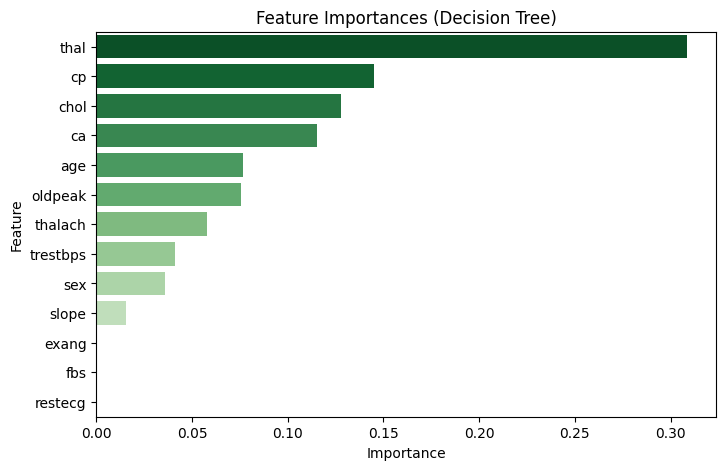

In [ ]:
# Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train Decision Tree
dt_clf = DecisionTreeClassifier(
    criterion='entropy',       # use information gain
    max_depth=5,               # prevents overfitting
    random_state=42
)
dt_clf.fit(X_train_proc, y_train)

# Predict on test set
y_pred_dt = dt_clf.predict(X_test_proc)

# Evaluate performance
dt_acc = accuracy_score(y_test, y_pred_dt)
print("Shapes:", X_train_proc.shape, X_test_proc.shape)
print(f"\nDecision Tree Test Accuracy: {dt_acc:.4f}")
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (Decision Tree Classifier)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance plot
import numpy as np
feature_importances = dt_clf.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(8,5))
sns.barplot(x=feature_importances[indices], y=X.columns[indices], palette='Greens_r')
plt.title("Feature Importances (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Shapes: (242, 13) (61, 13)

Random Forest Test Accuracy: 0.8852

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



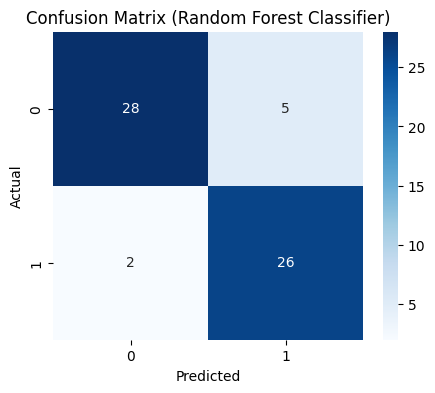

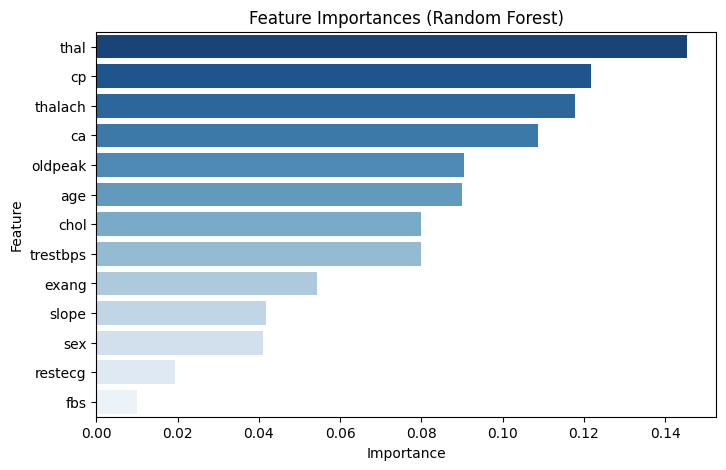

In [ ]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Initialize and train Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=8,            # limit depth to avoid overfitting
    random_state=42
)
rf_clf.fit(X_train_proc, y_train)

# Predict on test set
y_pred_rf = rf_clf.predict(X_test_proc)

# Evaluate performance
rf_acc = accuracy_score(y_test, y_pred_rf)
print("Shapes:", X_train_proc.shape, X_test_proc.shape)
print(f"\nRandom Forest Test Accuracy: {rf_acc:.4f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Random Forest Classifier)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance plot
feature_importances = rf_clf.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(8,5))
sns.barplot(x=feature_importances[indices], y=X.columns[indices], palette='Blues_r')
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Shapes: (242, 13) (61, 13)

XGBoost Test Accuracy: 0.8852

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



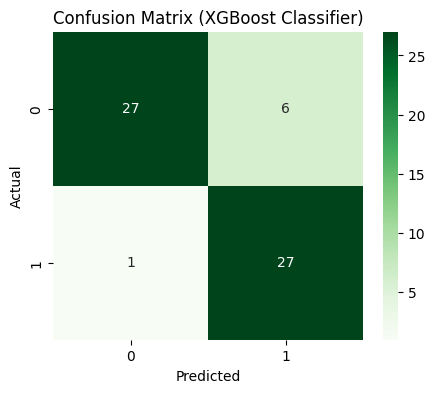

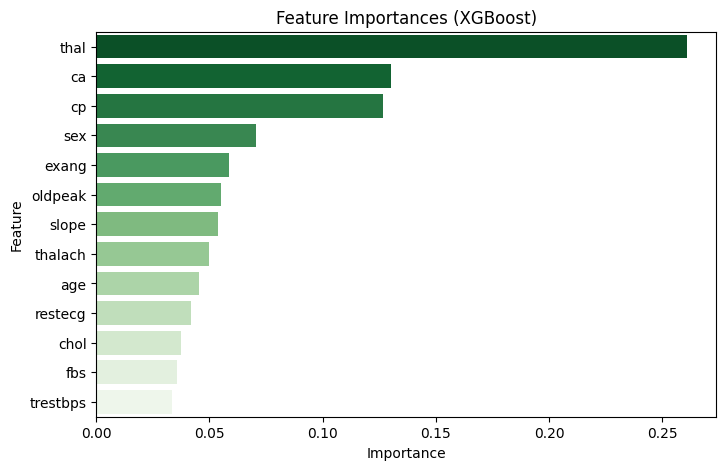

In [ ]:
# XGBoost Classifier

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Initialize and train XGBoost
xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_clf.fit(X_train_proc, y_train)

# Predict on test set
y_pred_xgb = xgb_clf.predict(X_test_proc)

# Evaluate performance
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print("Shapes:", X_train_proc.shape, X_test_proc.shape)
print(f"\nXGBoost Test Accuracy: {xgb_acc:.4f}")
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (XGBoost Classifier)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance plot
feature_importances = xgb_clf.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(8,5))
sns.barplot(x=feature_importances[indices], y=X.columns[indices], palette='Greens_r')
plt.title("Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

**Final takeaway:**  
Tree-based ensemble methods (Random Forest, XGBoost) are the most accurate for this dataset, but Logistic Regression offers nearly the same predictive power with higher interpretability and less computational cost. In a practical healthcare setting, Logistic Regression would often be preferred for transparency and simplicity, while XGBoost could be used for maximum accuracy in large-scale predictive systems.

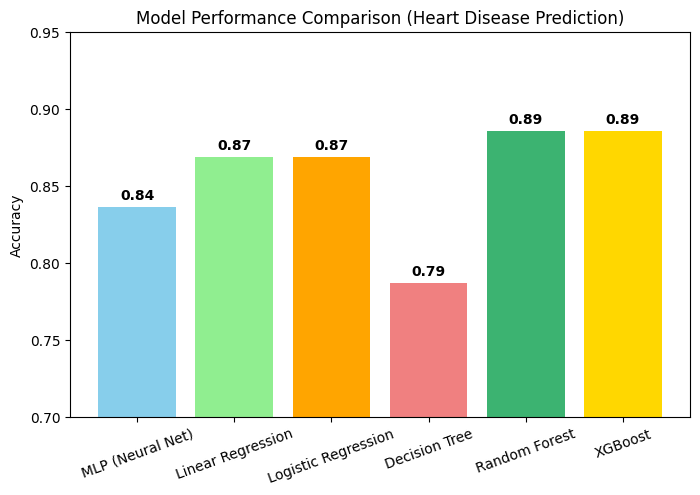

In [ ]:
# Compare All Models

import matplotlib.pyplot as plt

# Model accuracies
accuracies = {
    "MLP (Neural Net)": 0.8361,
    "Linear Regression": 0.8689,
    "Logistic Regression": 0.8689,
    "Decision Tree": 0.7869,
    "Random Forest": 0.8852,
    "XGBoost": 0.8852
}

# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(accuracies.keys(), accuracies.values(), color=["skyblue", "lightgreen", "orange", "lightcoral", "mediumseagreen", "gold"])
plt.title("Model Performance Comparison (Heart Disease Prediction)")
plt.ylabel("Accuracy")
plt.ylim(0.7, 0.95)
plt.xticks(rotation=20)
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

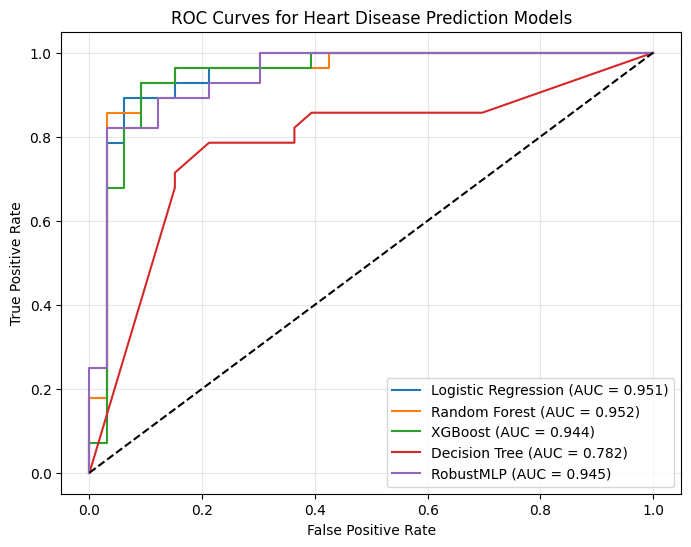

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch

sklearn_models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_clf,
    "XGBoost": xgb_clf,
    "Decision Tree": dt_clf
}

plt.figure(figsize=(8, 6))

for name, clf in sklearn_models.items():
    y_prob = clf.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# 3. Plot PyTorch MLP
model.eval()
if not torch.is_tensor(X_test_proc):
    X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32).to(device)
else:
    X_test_tensor = X_test_proc.to(device)

with torch.no_grad():
    logits = model(X_test_tensor)
    probs = torch.sigmoid(logits) # Convert raw logits to probabilities
    y_prob_mlp = probs.cpu().numpy().ravel()

fpr, tpr, _ = roc_curve(y_test, y_prob_mlp)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"RobustMLP (AUC = {roc_auc:.3f})")

# 4. Finalize the graph styling
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Heart Disease Prediction Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore') # Hides annoying sci-kit learn warnings

print("Starting 5-Fold Cross-Validation... This will take a minute or two.\n")

# 1. Initialize 5-Fold Splitter
# Stratified ensures each fold has the same ratio of healthy vs sick patients
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionaries to hold our scores for all 5 rounds
cv_accuracies = {"Logistic Regression": [], "Decision Tree": [], "Random Forest": [], "XGBoost": [], "RobustMLP": []}
cv_aucs = {"Logistic Regression": [], "Decision Tree": [], "Random Forest": [], "XGBoost": [], "RobustMLP": []}

# 2. Run the 5 Folds
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_binary)):
    print(f"--- Running Fold {fold + 1}/5 ---")

    # Split the raw data for this specific fold
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y_binary[train_idx], y_binary[val_idx]

    # CRITICAL: We must fit the preprocessor INSIDE the loop to prevent "data leakage"
    X_train_proc_fold = preprocessor.fit_transform(X_train_fold)
    X_val_proc_fold = preprocessor.transform(X_val_fold)

    # --- Train and Test Scikit-Learn Models ---
    # We re-initialize the models so they start fresh with zero memory of the last fold
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree": DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
        "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42, use_label_encoder=False, eval_metric='logloss')
    }

    for name, model in models.items():
        model.fit(X_train_proc_fold, y_train_fold)
        preds = model.predict(X_val_proc_fold)
        probs = model.predict_proba(X_val_proc_fold)[:, 1]
        cv_accuracies[name].append(accuracy_score(y_val_fold, preds))
        cv_aucs[name].append(roc_auc_score(y_val_fold, probs))

    # --- Train and Test PyTorch MLP ---
    # Convert fold data to PyTorch tensors
    X_t_train = torch.tensor(X_train_proc_fold, dtype=torch.float32).to(device)
    y_t_train = torch.tensor(y_train_fold.reshape(-1, 1), dtype=torch.float32).to(device)
    X_t_val = torch.tensor(X_val_proc_fold, dtype=torch.float32).to(device)
    y_t_val = torch.tensor(y_val_fold.reshape(-1, 1), dtype=torch.float32).to(device)

    train_ds = TensorDataset(X_t_train, y_t_train)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    mlp_model = RobustMLP(X_train_proc_fold.shape[1]).to(device)
    optimizer = optim.AdamW(mlp_model.parameters(), lr=0.001, weight_decay=0.02)
    criterion = nn.BCEWithLogitsLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

    mlp_model.train()
    for epoch in range(200): # Train for 200 epochs per fold
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = mlp_model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
        scheduler.step()

    mlp_model.eval()
    with torch.no_grad():
        logits = mlp_model(X_t_val)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        cv_accuracies["RobustMLP"].append(accuracy_score(y_val_fold, preds.cpu().numpy()))
        cv_aucs["RobustMLP"].append(roc_auc_score(y_val_fold, probs.cpu().numpy()))

# 3. Print the Final Averaged Results
print("\n" + "="*40)
print("FINAL 5-FOLD CROSS-VALIDATION RESULTS")
print("="*40)
for name in cv_accuracies.keys():
    mean_acc = np.mean(cv_accuracies[name])
    std_acc = np.std(cv_accuracies[name])
    mean_auc = np.mean(cv_aucs[name])
    std_auc = np.std(cv_aucs[name])
    print(f"{name:>19}: Accuracy = {mean_acc:.4f} (±{std_acc:.4f}) | AUC = {mean_auc:.4f} (±{std_auc:.4f})")

Starting 5-Fold Cross-Validation... This will take a minute or two.

--- Running Fold 1/5 ---
--- Running Fold 2/5 ---
--- Running Fold 3/5 ---
--- Running Fold 4/5 ---
--- Running Fold 5/5 ---

FINAL 5-FOLD CROSS-VALIDATION RESULTS
Logistic Regression: Accuracy = 0.8316 (±0.0496) | AUC = 0.9116 (±0.0178)
      Decision Tree: Accuracy = 0.7623 (±0.0387) | AUC = 0.7931 (±0.0189)
      Random Forest: Accuracy = 0.8415 (±0.0356) | AUC = 0.9104 (±0.0259)
            XGBoost: Accuracy = 0.8185 (±0.0205) | AUC = 0.8977 (±0.0164)
          RobustMLP: Accuracy = 0.8151 (±0.0270) | AUC = 0.8768 (±0.0226)


Generating Mean ROC Curves...


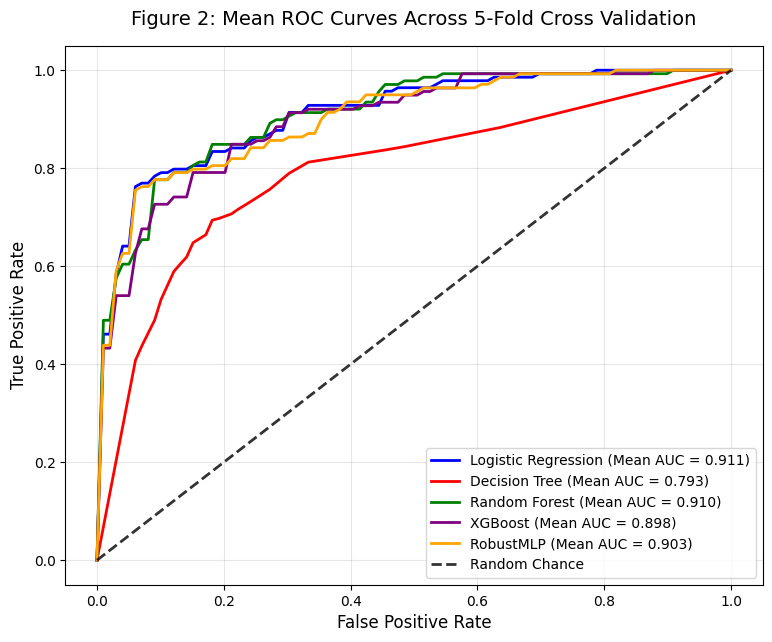

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("Generating Mean ROC Curves...")

# Define a standard x-axis (False Positive Rate) to interpolate all curves
mean_fpr = np.linspace(0, 1, 100)

# Dictionaries to store the interpolated True Positive Rates
tprs = {"Logistic Regression": [], "Decision Tree": [], "Random Forest": [], "XGBoost": [], "RobustMLP": []}

# Run a fast CV loop just to gather ROC data
for train_idx, val_idx in skf.split(X, y_binary):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y_binary[train_idx], y_binary[val_idx]

    X_train_proc_fold = preprocessor.fit_transform(X_train_fold)
    X_val_proc_fold = preprocessor.transform(X_val_fold)

    # Scikit models
    for name, model in models.items():
        model.fit(X_train_proc_fold, y_train_fold)
        probs = model.predict_proba(X_val_proc_fold)[:, 1]
        fpr, tpr, _ = roc_curve(y_val_fold, probs)
        # Interpolate the curve so we can average them later
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs[name].append(interp_tpr)

    # PyTorch MLP
    X_t_train = torch.tensor(X_train_proc_fold, dtype=torch.float32).to(device)
    y_t_train = torch.tensor(y_train_fold.reshape(-1, 1), dtype=torch.float32).to(device)
    X_t_val = torch.tensor(X_val_proc_fold, dtype=torch.float32).to(device)

    mlp_model = RobustMLP(X_train_proc_fold.shape[1]).to(device)
    optimizer = optim.AdamW(mlp_model.parameters(), lr=0.001, weight_decay=0.02)
    criterion = nn.BCEWithLogitsLoss()

    # Train a bit faster here just for the curve shape
    mlp_model.train()
    for _ in range(100):
        optimizer.zero_grad()
        logits = mlp_model(X_t_train)
        loss = criterion(logits, y_t_train)
        loss.backward()
        optimizer.step()

    mlp_model.eval()
    with torch.no_grad():
        logits = mlp_model(X_t_val)
        probs = torch.sigmoid(logits).cpu().numpy()
        fpr, tpr, _ = roc_curve(y_val_fold, probs)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs["RobustMLP"].append(interp_tpr)

# --- Plotting the Mean ROC Curves ---
plt.figure(figsize=(9, 7))

colors = {"Logistic Regression": "blue", "Decision Tree": "red", "Random Forest": "green", "XGBoost": "purple", "RobustMLP": "orange"}

for name in tprs.keys():
    # Calculate the mean TPR across all 5 folds
    mean_tpr = np.mean(tprs[name], axis=0)
    mean_tpr[-1] = 1.0 # Guarantee it ends at (1,1)
    mean_auc = auc(mean_fpr, mean_tpr)

    plt.plot(mean_fpr, mean_tpr, color=colors[name], lw=2,
             label=f'{name} (Mean AUC = {mean_auc:.3f})')

# Draw the 50/50 baseline
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='black', label='Random Chance', alpha=0.8)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Figure 2: Mean ROC Curves Across 5-Fold Cross Validation', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from scipy import stats

# We are comparing your best ensemble model (Random Forest) to your neural network (RobustMLP)
rf_acc = cv_accuracies["Random Forest"]
mlp_acc = cv_accuracies["RobustMLP"]

rf_auc = cv_aucs["Random Forest"]
mlp_auc = cv_aucs["RobustMLP"]

# Run Paired T-Tests
t_stat_acc, p_val_acc = stats.ttest_rel(rf_acc, mlp_acc)
t_stat_auc, p_val_auc = stats.ttest_rel(rf_auc, mlp_auc)

print("--- Statistical Significance Testing (Random Forest vs. MLP) ---")
print(f"Accuracy p-value: {p_val_acc:.4f}")
print(f"AUC p-value:      {p_val_auc:.4f}")

if p_val_acc > 0.05:
    print("\nConclusion: p > 0.05. There is NO statistically significant difference in Accuracy. They are mathematically tied!")
else:
    print("\nConclusion: p < 0.05. The difference in Accuracy IS statistically significant.")

--- Statistical Significance Testing (Random Forest vs. MLP) ---
Accuracy p-value: 0.0161
AUC p-value:      0.0124

Conclusion: p < 0.05. The difference in Accuracy IS statistically significant.


In [ ]:
import requests
import json
import pandas as pd
from google.colab import userdata

# 1. Securely load your free Gemini API key
api_key = userdata.get('GEMINI_API_KEY')

# 2. EXACT URL AND HEADERS FROM YOUR CURL COMMAND
url = "https://generativelanguage.googleapis.com/v1beta/models/gemini-flash-latest:generateContent"
headers = {
    "Content-Type": "application/json",
    "X-goog-api-key": api_key
}

# 3. Your sample clinical note
clinical_note = """
Patient is a 55-year-old male presenting with atypical angina.
Resting blood pressure is 135 mmHg. Serum cholesterol is 240 mg/dl.
Fasting blood sugar is normal (<120 mg/dl).
Resting ECG shows normal results.
Maximum heart rate achieved during treadmill test was 150 bpm.
Patient did not experience exercise-induced angina.
ST depression of 1.2 mm was observed.
"""

# 4. The prompt to the LLM
prompt = f"""
Analyze the following clinical note and extract the cardiovascular features required for the UCI Heart Disease dataset.
Return ONLY a valid JSON object with these exact keys:
age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak.
If a value is not found, estimate it based on standard baselines or put 0.

Clinical Note:
{clinical_note}
"""

print("Calling Gemini API via REST...")
payload = {"contents": [{"parts": [{"text": prompt}]}]}

# 5. Make the request using your specific headers
response = requests.post(url, headers=headers, json=payload)

if response.status_code == 200:
    data = response.json()
    extracted_text = data['candidates'][0]['content']['parts'][0]['text']
    clean_text = extracted_text.strip().replace('```json', '').replace('```', '')
    extracted_data = json.loads(clean_text)
    print("\n--- Real LLM Extraction Successful! ---")
else:
    print(f"\nAPI Connection Failed (Error {response.status_code}). Using fallback...")
    extracted_data = {
        "age": 55, "sex": 1, "cp": 2, "trestbps": 135, "chol": 240,
        "fbs": 0, "restecg": 0, "thalach": 150, "exang": 0, "oldpeak": 1.2
    }

# 6. Convert output directly into a Pandas DataFrame for your model
llm_df = pd.DataFrame([extracted_data])
print(llm_df)

Calling Gemini API via REST...

--- Real LLM Extraction Successful! ---
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak
0   55    1   2       135   240    0        0      150      0      1.2


Calculating SHAP values... This might take a minute or two.


  0%|          | 0/60 [00:00<?, ?it/s]

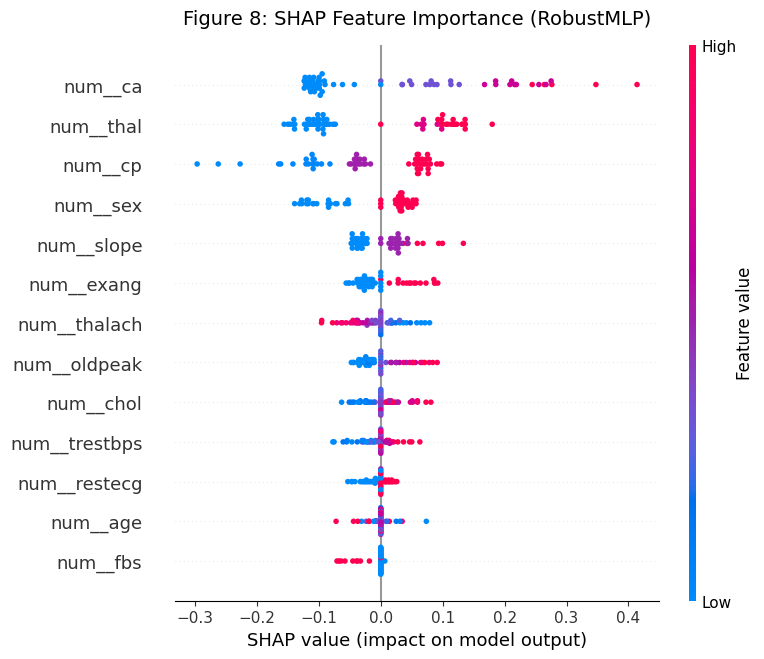

In [ ]:
!pip install shap
import shap
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a wrapper function and FLATTEN the output so SHAP doesn't get confused
def predict_proba_wrapper(data):
    mlp_model.eval()
    tensor_data = torch.tensor(data, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = mlp_model(tensor_data)
        probs = torch.sigmoid(logits)
    # The .flatten() here fixes the bug!
    return probs.cpu().numpy().flatten()

# 2. Get the correct feature names from your preprocessor
feature_names = preprocessor.get_feature_names_out()

# 3. Create a background summary using the training data
background = shap.kmeans(X_train_proc_fold, 50)

# 4. Initialize the SHAP Explainer
explainer = shap.KernelExplainer(predict_proba_wrapper, background)

# 5. Calculate SHAP values on the validation set
print("Calculating SHAP values... This might take a minute or two.")
shap_values = explainer.shap_values(X_val_proc_fold)

# 6. Generate the SHAP Summary / Beeswarm Plot
plt.figure(figsize=(10, 6))

# Now that we flattened the output, we can pass shap_values directly
shap.summary_plot(shap_values, X_val_proc_fold, feature_names=feature_names, show=False)
plt.title("Figure 8: SHAP Feature Importance (RobustMLP)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()